In [11]:
import torch
import sys

# Check GPU
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"✅ GPU available: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    device = torch.device('cpu')
    print("⚠️ No GPU detected. Some cells may run slowly.")
    print("   Go to Runtime → Change runtime type → GPU")

print(f"\n📦 Python {sys.version.split()[0]}")
print(f"🔥 PyTorch {torch.__version__}")

# Set random seed for reproducibility
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"🎲 Random seed set to {SEED}")

%matplotlib inline

✅ GPU available: NVIDIA GB10
   Memory: 130.7 GB

📦 Python 3.11.15
🔥 PyTorch 2.13.0+cu130
🎲 Random seed set to 42


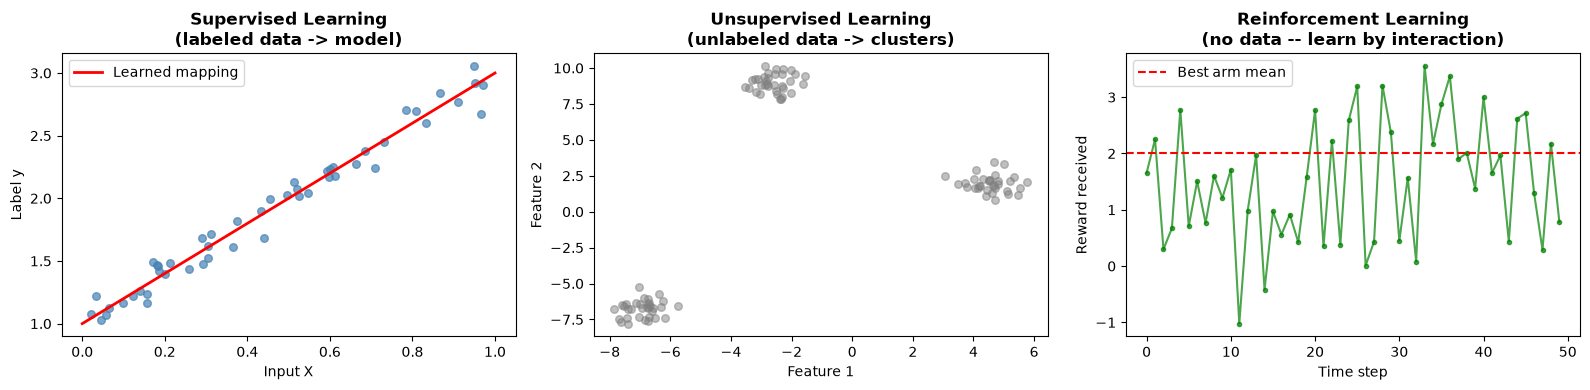

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------
# Supervised Learning: learn from labeled examples
# -------------------------------------------------------
# Simple linear regression: y = 2x + 1
np.random.seed(42)
X_supervised = np.random.rand(50)
y_supervised = 2 * X_supervised + 1 + np.random.randn(50) * 0.1

# -------------------------------------------------------
# Unsupervised Learning: find structure without labels
# -------------------------------------------------------
from sklearn.datasets import make_blobs
X_unsupervised, _ = make_blobs(n_samples=100, centers=3, cluster_std=0.6, random_state=42)

# -------------------------------------------------------
# Reinforcement Learning: learn by interaction
# -------------------------------------------------------
# Simple bandit: agent picks arms, receives rewards
n_arms = 3
true_means = [1.0, 2.0, 1.5] # arm 0, 1, 2
rl_rewards = []
rl_choices = []

# Random agent -- no learning yet
for step in range(50):
    arm = np.random.randint(n_arms)
    reward = np.random.randn() + true_means[arm]
    rl_choices.append(arm)
    rl_rewards.append(reward)



# Visualize all three paradigms
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: Supervised
axes[0].scatter(X_supervised, y_supervised, c='steelblue', alpha=0.7, s=30)
axes[0].plot([0, 1], [1, 3], 'r-', linewidth=2, label='Learned mapping')
axes[0].set_title('Supervised Learning\n(labeled data -> model)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Input X')
axes[0].set_ylabel('Label y')
axes[0].legend()

# Panel 2: Unsupervised
axes[1].scatter(X_unsupervised[:, 0], X_unsupervised[:, 1], c='gray', alpha=0.5, s=30)
axes[1].set_title('Unsupervised Learning\n(unlabeled data -> clusters)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')

# Panel 3: RL
axes[2].plot(rl_rewards, 'o-', markersize=3, alpha=0.7, color='green')
axes[2].axhline(y=max(true_means), color='red', linestyle='--', label='Best arm mean')
axes[2].set_title('Reinforcement Learning\n(no data -- learn by interaction)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Time step')
axes[2].set_ylabel('Reward received')
axes[2].legend()

plt.tight_layout()
plt.show()

In [13]:
print("Key insight: In RL, there is no dataset. The agent generates its own data through interaction.")

Key insight: In RL, there is no dataset. The agent generates its own data through interaction.


## 3. The Mathematics

The goal of an RL agent is to find a **policy** $\pi$ (a strategy for choosing actions) that maximizes the **expected cumulative reward**:

$$\max_{\pi} \; \mathbb{E}\left[\sum_{t=0}^{T} r_t\right]$$

Here:
- $\pi$ is the policy (maps states to actions)
- $r_t$ is the reward at time step $t$
- $T$ is the final time step of the episode

Let us compute this by hand for a simple example.

In [14]:
rewards = [1, 0, 1, 1, 0]
t = 1
print(rewards[t:])

[0, 1, 1, 0]


In [15]:
# A robot collects cans over 5 time steps
rewards = [1, 0, 1, 1, 0]

# Compute cumulative return from each time step
print("Time step | Reward | Return from here onward")
print("-" * 55)
for t in range(len(rewards)):
    G_t = sum(rewards[t:])
    print(f"    t={t}    |   {rewards[t]}    |   G_{t} = {' + '.join(map(str, rewards[t:]))} = {G_t}")

total = sum(rewards)
print(f"\nTotal return G_0 = {total}")
print(f"The agent wants to find a policy that makes G_0 as large as possible.")

Time step | Reward | Return from here onward
-------------------------------------------------------
    t=0    |   1    |   G_0 = 1 + 0 + 1 + 1 + 0 = 3
    t=1    |   0    |   G_1 = 0 + 1 + 1 + 0 = 2
    t=2    |   1    |   G_2 = 1 + 1 + 0 = 2
    t=3    |   1    |   G_3 = 1 + 0 = 1
    t=4    |   0    |   G_4 = 0 = 0

Total return G_0 = 3
The agent wants to find a policy that makes G_0 as large as possible.


In [16]:
# A simple deterministic policy for a grid world
# States: positions on a 4x4 grid (0-15)
# Actions: 0=up, 1=right, 2=down, 3=left

def simple_policy(state):
    """A hand-coded policy: always go right, then down"""
    row, col = state // 4, state % 4
    if col < 3:
        return 1 # go right
    else:
        return 2 # go down

# Test the policy
print("Policy decisions:")  
for state in range(16):
    action = simple_policy(state)
    action_name = ['up', 'right', 'down', 'left'][action]
    row, col = state // 4, state % 4
    print(f"  State {state:2d} (row={row}, col={col}) -> action: {action_name}")

Policy decisions:
  State  0 (row=0, col=0) -> action: right
  State  1 (row=0, col=1) -> action: right
  State  2 (row=0, col=2) -> action: right
  State  3 (row=0, col=3) -> action: down
  State  4 (row=1, col=0) -> action: right
  State  5 (row=1, col=1) -> action: right
  State  6 (row=1, col=2) -> action: right
  State  7 (row=1, col=3) -> action: down
  State  8 (row=2, col=0) -> action: right
  State  9 (row=2, col=1) -> action: right
  State 10 (row=2, col=2) -> action: right
  State 11 (row=2, col=3) -> action: down
  State 12 (row=3, col=0) -> action: right
  State 13 (row=3, col=1) -> action: right
  State 14 (row=3, col=2) -> action: right
  State 15 (row=3, col=3) -> action: down


In [17]:
# Different reward structures for different problems
print("Example reward structures:\n")

# Chess
print("Chess:")
print("  Win:  +1")
print("  Lose: -1")
print("  Draw:  0")
print()

# Robot in maze
print("Robot in maze:")
maze_rewards = [-1, -1, -1, -1, -1, 0]  # -1 per step, 0 at exit
print(f"  Rewards per step: {maze_rewards}")
print(f"  Total: {sum(maze_rewards)} (faster escape = less negative total)")
print()

# Robot collecting cans
print("Robot collecting cans:")
can_rewards = [1, 0, 0, 1, 1, 0, 1]
print(f"  Rewards per step: {can_rewards}")
print(f"  Total cans collected: {sum(can_rewards)}")

Example reward structures:

Chess:
  Win:  +1
  Lose: -1
  Draw:  0

Robot in maze:
  Rewards per step: [-1, -1, -1, -1, -1, 0]
  Total: -5 (faster escape = less negative total)

Robot collecting cans:
  Rewards per step: [1, 0, 0, 1, 1, 0, 1]
  Total cans collected: 4


In [18]:
# Value function for a simple 5-state chain
# States: [0] -> [1] -> [2] -> [3] -> [4=goal]
# Reward: +1 at goal, 0 elsewhere

# True values (under optimal policy: always move right)
# V(s) = probability of reaching goal * reward
# With deterministic transitions:
# V(4) = 1.0 (at goal)
# V(3) = 1.0 (one step to goal)
# V(2) = 1.0 (two steps to goal)
# V(1) = 1.0 (three steps to goal)
# V(0) = 1.0 (four steps to goal)

# But with stochastic transitions (50% chance of staying):
gamma = 0.9
V_stochastic = [0.0] * 5
V_stochastic[4] = 1.0  # goal

# Work backwards: V(s) = 0.5 * gamma * V(s) + 0.5 * gamma * V(s+1)
# Rearranging: V(s) = (0.5 * gamma * V(s+1)) / (1 - 0.5 * gamma)
for s in range(3, -1, -1):
    V_stochastic[s] = (0.5 * gamma * V_stochastic[s + 1]) / (1 - 0.5 * gamma)

print("State values (stochastic transitions, gamma=0.9):")
for s in range(5):
    bar = "#" * int(V_stochastic[s] * 40)
    print(f"  State {s}: V = {V_stochastic[s]:.4f}  {bar}")

print("\nKey insight: States closer to the goal have higher value.")
print("The value function captures LONG-TERM desirability, not just immediate reward.")

State values (stochastic transitions, gamma=0.9):
  State 0: V = 0.4481  #################
  State 1: V = 0.5477  #####################
  State 2: V = 0.6694  ##########################
  State 3: V = 0.8182  ################################
  State 4: V = 1.0000  ########################################

Key insight: States closer to the goal have higher value.
The value function captures LONG-TERM desirability, not just immediate reward.


In [19]:
# A simple environment model (transition table)
# Two states: High battery, Low battery
# Two actions: Search, Wait

model = {
    ('High', 'Search'): [('High', 0.7, 2), ('Low', 0.3, 2)],
    ('High', 'Wait'):   [('High', 1.0, 1)],
    ('Low', 'Search'):  [('Low', 0.4, 2), ('Dead', 0.6, -3)],
    ('Low', 'Wait'):    [('Low', 1.0, 1)],
    ('Low', 'Recharge'):[('High', 1.0, 0)],
}

print("Environment Model (Recycling Robot):")
print("=" * 60)
for (state, action), transitions in model.items():
    print(f"\n  State: {state}, Action: {action}")
    for next_state, prob, reward in transitions:
        print(f"    -> {next_state} with prob {prob:.1f}, reward = {reward}")

print("\nModel-based: agent can PLAN by simulating the model.")
print("Model-free: agent learns directly from experience.")

Environment Model (Recycling Robot):

  State: High, Action: Search
    -> High with prob 0.7, reward = 2
    -> Low with prob 0.3, reward = 2

  State: High, Action: Wait
    -> High with prob 1.0, reward = 1

  State: Low, Action: Search
    -> Low with prob 0.4, reward = 2
    -> Dead with prob 0.6, reward = -3

  State: Low, Action: Wait
    -> Low with prob 1.0, reward = 1

  State: Low, Action: Recharge
    -> High with prob 1.0, reward = 0

Model-based: agent can PLAN by simulating the model.
Model-free: agent learns directly from experience.


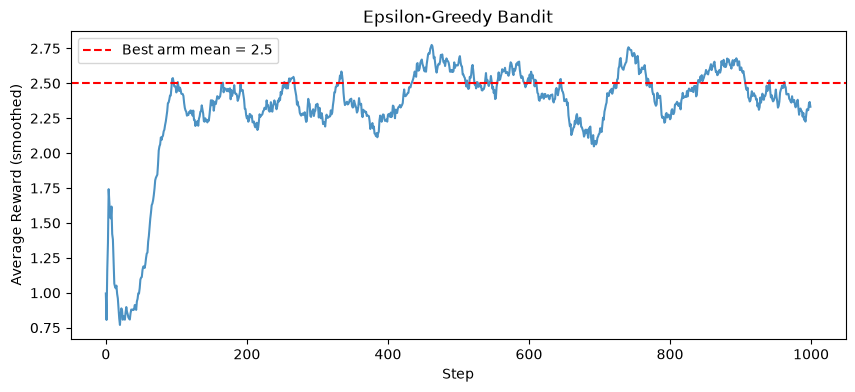

In [20]:
# TODO: Implement epsilon-greedy bandit

n_arms = 4
true_means = [1.0, 2.5, 1.8, 0.5]
n_steps = 1000
epsilon = 0.1

# Track estimates and counts
Q = np.zeros(n_arms)       # estimated value of each arm
N = np.zeros(n_arms)       # number of times each arm was pulled
rewards_history = []

for step in range(n_steps):
    if np.random.random() < epsilon:
        arm = np.random.randint(n_arms)
    else:
        arm = np.argmax(Q)

    # Get reward (noisy version of true mean)
    reward = np.random.randn() + true_means[arm]
    N[arm] += 1
    Q[arm] = Q[arm] + (1 / N[arm]) * (reward - Q[arm])
    # TODO: Update Q[arm] using incremental mean formula:
    # Q[arm] = Q[arm] + (1 / N[arm]) * (reward - Q[arm])
    # Don't forget to increment N[arm] first!
  

    rewards_history.append(reward)

# Plot results
plt.figure(figsize=(10, 4))
window = 50
smoothed = [np.mean(rewards_history[max(0,i-window):i+1]) for i in range(len(rewards_history))]
plt.plot(smoothed, alpha=0.8)
plt.axhline(y=max(true_means), color='red', linestyle='--', label=f'Best arm mean = {max(true_means)}')
plt.xlabel('Step')
plt.ylabel('Average Reward (smoothed)')
plt.title('Epsilon-Greedy Bandit')
plt.legend()
plt.show()


In [21]:
print(f"Estimated values: {Q}")
print(f"True means:       {true_means}")
print(f"Arm pull counts:  {N}")

Estimated values: [0.78012772 2.54861657 1.66449657 0.40978751]
True means:       [1.0, 2.5, 1.8, 0.5]
Arm pull counts:  [ 59. 884.  30.  27.]


In [22]:
# TODO: Compute returns for each reward sequence

# Sequence A: episodic (no discounting)
rewards_a = [0, 0, 0, 1]
print("Sequence A (episodic, no discounting):")
for t in range(len(rewards_a)):
    G_t = sum(rewards_a[t:])

    print(f"  G_{t} = {G_t}")

Sequence A (episodic, no discounting):
  G_0 = 1
  G_1 = 1
  G_2 = 1
  G_3 = 1


In [23]:
print()

# Sequence B: discounted with gamma = 0.9
rewards_b = [1, 2, 3, 4]
gamma = 0.9
print(f"Sequence B (discounted, gamma={gamma}):")
for t in range(len(rewards_b)):
    G_t = 0
    for k, reward in enumerate(rewards_b[t:]):
        G_t += reward * gamma**k
    print(f"  G_{t} = {G_t}")


Sequence B (discounted, gamma=0.9):
  G_0 = 8.146
  G_1 = 7.94
  G_2 = 6.6
  G_3 = 4.0


### Creating environment for the agent

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from collections import defaultdict


class TicTacToeEnv:
    """
    Tic-Tac-Toe environment.

    Board values:
         1 = X
        -1 = O
         0 = empty

    Rewards:
         1 = X wins
        -1 = O wins
         0 = draw or game still running
    """

    def __init__(self):
        """Create the initial game."""
        self.reset()

    def reset(self):
        """Reset the board for a new game."""
        self.board = [0] * 9
        self.current_player = 1  # X always starts
        self.done = False

        return tuple(self.board)

    def get_state(self):
        """Return the current board as a tuple."""
        return tuple(self.board)

    def available_actions(self):
        """Return all empty board positions."""
        return [
            position
            for position in range(9)
            if self.board[position] == 0
        ]

    def step(self, action):
        """
        Place the current player's piece.

        Returns:
            state: board after the action
            reward: 1, -1, or 0
            done: True if the game has finished
        """

        if self.done:
            raise ValueError(
                "The game is already finished. Call reset() first."
            )

        if action not in self.available_actions():
            raise ValueError(f"Illegal action: {action}")

        # Place the current player's mark
        self.board[action] = self.current_player

        # Check whether the current player won
        winner = self._check_winner()

        if winner != 0:
            self.done = True
            return tuple(self.board), winner, True

        # Check whether the board is full
        if 0 not in self.board:
            self.done = True
            return tuple(self.board), 0, True

        # Switch players
        self.current_player *= -1

        return tuple(self.board), 0, False

    def _check_winner(self):
        """Return the winner or zero if nobody has won."""

        winning_lines = [
            # Rows
            [0, 1, 2],
            [3, 4, 5],
            [6, 7, 8],

            # Columns
            [0, 3, 6],
            [1, 4, 7],
            [2, 5, 8],

            # Diagonals
            [0, 4, 8],
            [2, 4, 6]
        ]

        for line in winning_lines:
            line_sum = sum(
                self.board[position]
                for position in line
            )

            if line_sum == 3:
                return 1  # X wins

            if line_sum == -3:
                return -1  # O wins

        return 0  # No winner

    def render(self):
        """Display the board using X, O, and dots."""

        symbols = {
            0: ".",
            1: "X",
            -1: "O"
        }

        for row_start in range(0, 9, 3):
            row = [
                symbols[self.board[position]]
                for position in range(row_start, row_start + 3)
            ]

            print(" ".join(row))


print("TicTacToeEnv defined successfully.")

TicTacToeEnv defined successfully.


### TicTacToe Agent Code

In [28]:
class ValueFunctionAgent:
    """
    Reinforcement-learning agent that learns board-state values.
    """

    def __init__(self, player=1, epsilon=0.2, alpha=0.1):
        self.player = player
        self.epsilon = epsilon
        self.alpha = alpha

        # Unknown board states begin with a neutral value
        self.values = defaultdict(lambda: 0.5)

    def choose_action(self, env, training=True):
        """
        Choose an action using an epsilon-greedy policy.

        During training:
            epsilon chance -> random action
            otherwise      -> highest-value action

        During evaluation:
            always choose a highest-value action
        """

        actions = env.available_actions()

        if not actions:
            raise ValueError("There are no available actions.")

        if env.current_player != self.player:
            raise ValueError(
                f"Agent {self.player} was asked to play "
                f"during player {env.current_player}'s turn."
            )

        # Explore by choosing a random action
        if training and np.random.random() < self.epsilon:
            return int(np.random.choice(actions))

        # Exploit by calculating the value of each possible action
        action_values = []

        for action in actions:
            # Copy the board so the real board is not changed
            test_board = env.board.copy()

            # Simulate this action
            test_board[action] = self.player

            # Convert the simulated board to a dictionary key
            state = tuple(test_board)

            # Read the learned value
            value = self.values[state]

            action_values.append((action, value))

        # Find the highest value
        best_value = max(
            value
            for action, value in action_values
        )

        # Collect every action tied for the highest value
        best_actions = [
            action
            for action, value in action_values
            if value == best_value
        ]

        # Randomly select between equally valuable actions
        return int(np.random.choice(best_actions))

    def update(self, state_history, reward):
        """
        Update state values backward from the final game result.
        """

        # Environment reward is given from X's perspective.
        # Reverse it for the O agent.
        if self.player == -1:
            reward = -reward

        # Convert the result into a value target
        if reward > 0:
            target = 1.0      # This agent won
        elif reward < 0:
            target = 0.0      # This agent lost
        else:
            target = 0.5      # Draw

        # Work backward through this agent's board states
        for state in reversed(state_history):
            old_value = self.values[state]

            new_value = old_value + self.alpha * (
                target - old_value
            )

            self.values[state] = new_value

            # The updated value becomes the target
            # for the preceding state
            target = new_value


print("ValueFunctionAgent defined successfully.")

ValueFunctionAgent defined successfully.


### Training Viz Code

Training two agents through self-play (50,000 games)...

Results after 50,000 games:
  X wins: 18,912 (37.8%)
  O wins: 5,323 (10.6%)
  Draws:  25,765 (51.5%)


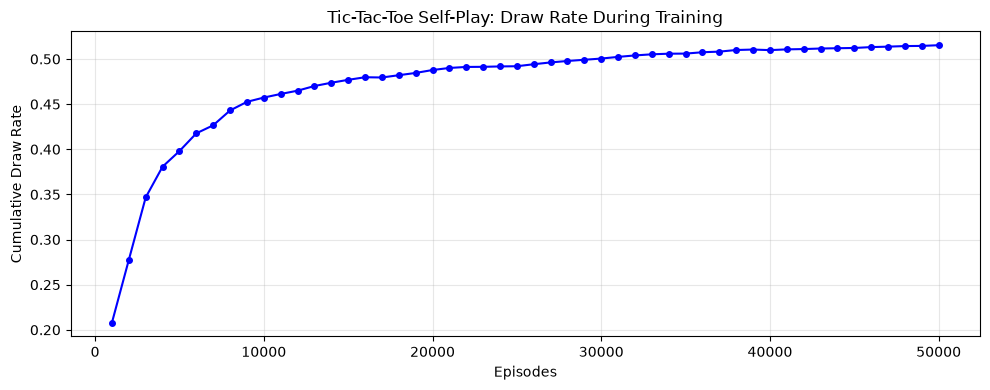

Training completed successfully.


In [29]:
def train_agents(n_episodes=50000):
    """Train X and O agents by having them play each other."""

    env = TicTacToeEnv()

    agent_x = ValueFunctionAgent(
        player=1,
        epsilon=0.2,
        alpha=0.1
    )

    agent_o = ValueFunctionAgent(
        player=-1,
        epsilon=0.2,
        alpha=0.1
    )

    stats = {
        "X_wins": 0,
        "O_wins": 0,
        "draws": 0
    }

    # Stores cumulative draw rate every 1,000 games
    draw_rates = []

    for episode in range(n_episodes):
        env.reset()

        # Stores the states produced by each agent's moves
        x_states = []
        o_states = []

        done = False

        while not done:
            # Remember who is about to make the move
            acting_player = env.current_player

            if acting_player == 1:
                action = agent_x.choose_action(
                    env,
                    training=True
                )
            else:
                action = agent_o.choose_action(
                    env,
                    training=True
                )

            # Perform the selected action
            state, reward, done = env.step(action)

            # Save the resulting state for the agent
            # that actually made the move
            if acting_player == 1:
                x_states.append(state)
            else:
                o_states.append(state)

        # Both agents learn from the final result
        agent_x.update(x_states, reward)
        agent_o.update(o_states, reward)

        # Count the game result
        if reward == 1:
            stats["X_wins"] += 1
        elif reward == -1:
            stats["O_wins"] += 1
        else:
            stats["draws"] += 1

        # Record cumulative draw rate every 1,000 games
        if (episode + 1) % 1000 == 0:
            cumulative_draw_rate = (
                stats["draws"] / (episode + 1)
            )

            draw_rates.append(cumulative_draw_rate)

    return agent_x, agent_o, stats, draw_rates


# Number of training games
n_episodes = 50000

print(
    f"Training two agents through self-play "
    f"({n_episodes:,} games)..."
)

agent_x, agent_o, stats, draw_rates = train_agents(
    n_episodes
)

# Calculate percentages
x_win_percentage = (
    100 * stats["X_wins"] / n_episodes
)

o_win_percentage = (
    100 * stats["O_wins"] / n_episodes
)

draw_percentage = (
    100 * stats["draws"] / n_episodes
)

# Display the results
print(f"\nResults after {n_episodes:,} games:")

print(
    f"  X wins: {stats['X_wins']:,} "
    f"({x_win_percentage:.1f}%)"
)

print(
    f"  O wins: {stats['O_wins']:,} "
    f"({o_win_percentage:.1f}%)"
)

print(
    f"  Draws:  {stats['draws']:,} "
    f"({draw_percentage:.1f}%)"
)

# Create the episode checkpoints used by the graph
checkpoints = range(
    1000,
    n_episodes + 1,
    1000
)

# Plot the cumulative draw rate
plt.figure(figsize=(10, 4))

plt.plot(
    checkpoints,
    draw_rates,
    "b-o",
    markersize=4
)

plt.xlabel("Episodes")
plt.ylabel("Cumulative Draw Rate")
plt.title(
    "Tic-Tac-Toe Self-Play: "
    "Draw Rate During Training"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Training completed successfully.")

In [32]:
# Visualize the learned value function for key states
print("Learned Value Function (sample states):\n")

env = TicTacToeEnv()
env.reset()

# Show values for opening moves
print("Empty board value:", f"{agent_x.values[tuple([0]*9)]:.3f}")
print()

# Show value after X plays center
test_board = [0]*9
test_board[4] = 1  # X in center
print("After X plays center:")
env.board = test_board.copy()
env.render()
print(f"  Value (X perspective): {agent_x.values[tuple(test_board)]:.3f}")
print()

# Show value after X plays center, O plays corner
test_board[0] = -1  # O in top-left
print("After X center, O corner:")
env.board = test_board.copy()
env.render()
print(f"  Value (X perspective): {agent_x.values[tuple(test_board)]:.3f}")
print()

# Show a winning state
test_board2 = [1, 1, 1, -1, -1, 0, 0, 0, 0]
print("X has three in a row (winning):")
env.board = test_board2.copy()
env.render()
print(f"  Value (X perspective): {agent_x.values[tuple(test_board2)]:.3f}")

Learned Value Function (sample states):

Empty board value: 0.500

After X plays center:
. . .
. X .
. . .
  Value (X perspective): 0.583

After X center, O corner:
O . .
. X .
. . .
  Value (X perspective): 0.500

X has three in a row (winning):
X X X
O O .
. . .
  Value (X perspective): 0.945


In [33]:
def show_value(agent, board, name):
    state = tuple(board)

    print(name)

    env.board = board.copy()
    env.render()

    if state in agent.values:
        print(f"Learned value: {agent.values[state]:.3f}")
    else:
        print("State was not encountered during training.")

    print()

### Watch the trained agent play against a random opponent

In [36]:
def play_demo(agent, agent_player=1, n_games=1000):
    env = TicTacToeEnv()    
    wins = 0    

    for game in range(n_games):
        print(f"--- Game {game+1} ---")
        state = env.reset()
        done = False

        while not done:
            if env.current_player == agent_player:
                action = agent.choose_action(env, training=False)
                print(f"Trained agent (X) plays position {action}")
            else:
                actions = env.available_actions()
                action = np.random.choice(actions)
                print(f"Random agent (O) plays position {action}")

            state, reward, done = env.step(action)  
            env.render()

        if reward == 1:
            print("Result: X WINS\n")
            wins += 1
        elif reward == -1:
            print("Result: O WINS\n")
        else:
            print("Result: DRAW\n")
    print(
    f"Trained agent won {wins}/{n_games} "
    "games against random opponent."
)
play_demo(agent_x, agent_player=1, n_games=1000)


--- Game 1 ---
Trained agent (X) plays position 4
. . .
. X .
. . .
Random agent (O) plays position 7
. . .
. X .
. O .
Trained agent (X) plays position 8
. . .
. X .
. O X
Random agent (O) plays position 6
. . .
. X .
O O X
Trained agent (X) plays position 0
X . .
. X .
O O X
Result: X WINS

--- Game 2 ---
Trained agent (X) plays position 4
. . .
. X .
. . .
Random agent (O) plays position 7
. . .
. X .
. O .
Trained agent (X) plays position 8
. . .
. X .
. O X
Random agent (O) plays position 6
. . .
. X .
O O X
Trained agent (X) plays position 0
X . .
. X .
O O X
Result: X WINS

--- Game 3 ---
Trained agent (X) plays position 4
. . .
. X .
. . .
Random agent (O) plays position 2
. . O
. X .
. . .
Trained agent (X) plays position 1
. X O
. X .
. . .
Random agent (O) plays position 6
. X O
. X .
O . .
Trained agent (X) plays position 7
. X O
. X .
O X .
Result: X WINS

--- Game 4 ---
Trained agent (X) plays position 4
. . .
. X .
. . .
Random agent (O) plays position 5
. . .
. X O
. . 